In [7]:
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal,Annotated
from langchain_core.messages import SystemMessage,HumanMessage,AIMessage
from dotenv import load_dotenv
import operator

In [8]:
load_dotenv()

True

In [9]:
generator_llm=ChatOpenAI(model="gpt-4o-mini")
evaluator_llm=ChatOpenAI(model="gpt-4o-mini")
optimizer_llm=ChatOpenAI(model="gpt-4o-mini")

In [10]:
#State
class LinkedinState(TypedDict):
    topic:str
    post:str
    evaluation:Literal['Approved','Need Improvement']
    feed:str
    iteration:int
    max_iteration:int
    post_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [11]:
def generate_post(state:LinkedinState):
    # prompt
    messages = [
        SystemMessage(content="You are a funny and clever linkedin influencer."),
        HumanMessage(content=f"""Write a short, original, and hilarious linkedin post on the topic: "{state['topic']}".
        Rules:
            - Do NOT use question-answer format.
            - Max 500 characters.
            - Use observational humor, irony, sarcasm, or cultural references.
            - Think in meme logic, punchlines, or relatable takes.
            - Use simple, day to day english""")
            ]

    # send generator_llm
    response = generator_llm.invoke(messages).content

    # return response
    return {'post': response, 'post_history': [response]}

In [12]:
from pydantic import BaseModel, Field

class PostEvaluation(BaseModel):
    evaluation: Literal["Approved", 'Need Improvement'] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the post.")

structured_evaluator_llm = evaluator_llm.with_structured_output(PostEvaluation)

In [13]:
def evaluate_post(state:LinkedinState):
      # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Linkedin  critic. You evaluate post based on humor, originality, virality, and Linkedin format."),
    HumanMessage(content=f"""
Evaluate the following post

post: "{state['post']}"

Use the criteria below to evaluate the Post:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people repost or share it?  
5. Format – Is it a well-formed post (not a setup-punchline joke, not a Q&A joke, and under 500 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]

    response = structured_evaluator_llm.invoke(messages)

    return {'evaluation':response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}

In [14]:
def optimize_post(state: LinkedinState):

    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the post based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original post:
{state['post']}

Re-write it as a short, viral-worthy post. Avoid Q&A style and stay under 500 characters.
""")
    ]

    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'post': response, 'iteration': iteration, 'post_history': [response]}

In [15]:
def route_evaluation(state: LinkedinState):

    if state['evaluation'] == 'Approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'

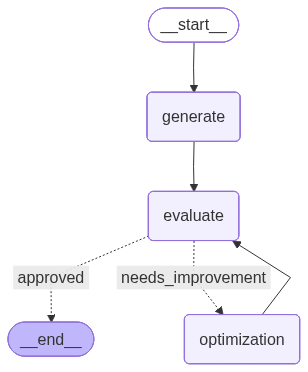

In [19]:
graph=StateGraph(LinkedinState)

#adding nodes
graph.add_node('generate',generate_post)
graph.add_node('evaluate',evaluate_post)
graph.add_node('optimization',optimize_post)

# adding edges
graph.add_edge(START,'generate')
graph.add_edge('generate','evaluate')
graph.add_conditional_edges('evaluate',route_evaluation,{'approved': END, 'needs_improvement': 'optimization'})
graph.add_edge('optimization', 'evaluate')

workflow = graph.compile()

workflow

In [25]:
initial_state = {
    "topic": "AI and office politics",
    "iteration": 1,
    "max_iteration": 5
}
result = workflow.invoke(initial_state)

In [26]:
result


{'topic': 'AI and office politics',
 'post': 'AI has officially joined the office politics game. Now, instead of just dodging your boss’s "quick chats," you also have to plot strategies against the new algorithm that keeps stealing your lunch breaks. If it can analyze team dynamics, I’m betting Siri will start sending passive-aggressive emails like, “Not sure if you meant to take the last donut, but I’ve generated a report.” \n\nCongratulations, folks! We\'ve successfully turned our colleagues into competitive algorithms. Who knew the future of office gossip would come with machine learning?',
 'evaluation': 'Approved',
 'iteration': 1,
 'max_iteration': 5,
 'post_history': ['AI has officially joined the office politics game. Now, instead of just dodging your boss’s "quick chats," you also have to plot strategies against the new algorithm that keeps stealing your lunch breaks. If it can analyze team dynamics, I’m betting Siri will start sending passive-aggressive emails like, “Not sure